# Predicting Chess Game Outcomes Using the First 15 Moves
**Student:** Artem Okhten  
**Course:** MTH 4224 – Intro to Machine Learning  
**Term:** Spring 2026

## 1. Introduction
The primary objective of this project is to determine whether the outcome of a chess game can be predicted with high accuracy using solely the information available after the first 15 moves. By restricting the temporal scope of the data utilized, this study explores the limits of the predictive power of positional advantages that emerge during the early stages of the game.

To address this challenge, we formulate the problem as a multiclass classification task. We will develop a comprehensive set of domain-specific features, implement rigorous measures to prevent data leakage, and train a suite of machine learning algorithms; furthermore, we will apply game-theory-based interpretation methods (SHAP) to identify precisely which features exert the most significant influence on the course and outcome of the game.

In [1]:
import os
import time
import chess
import chess.pgn
import chess.engine
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import warnings

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report, roc_auc_score
from imblearn.over_sampling import SMOTE

shap.initjs()

## 2. Configuration & Setup
We define a centralized configuration dictionary to manage data paths, computational constraints, and model training states. This ensures reproducibility and ease of scaling.

In [2]:
config = {
    'data': {
        'pgn_path': 'lichess_data.pgn',
        'csv_path': 'chess_dataset_parsed.csv',
        'max_games': 10000
    },
    'engine': {
        'path': r"C:\Users\darha\Documents\MTH 4224\project1\stockfish\stockfish.exe",
        'time_limit': 0.1
    },
    'training': {
        'test_size': 0.2,
        'random_state': 42,
        'use_smote': True
    }
}

## 3. Dataset Description & Feature Engineering

**Data Source:** This dataset was obtained from the Lichess database (`database.lichess.org`) using the standard PGN (Portable Game Notation) format.

**Dataset Summary**

| Metric | Count / Percentage |
| :--- | :--- |
| **Total games analyzed** | ~ 10,000 |
| **Training set size** | ~ 8,000 |
| **Test set size** | ~ 2,000 |

**Outcome Distribution (Class Imbalance):**
* **White Win (2):** ~ 51%
* **Black Win (0):** ~ 45%
* **Draw (1):** ~ 4%

For a machine learning model to process board games, it is necessary to transform the spatial and logical states of the game board into numerical vectors. Using the `python-chess` library, we simulate the first 15 moves and extract the following extended heuristic features:

| Feature Name | Description | Type |
| :--- | :--- | :--- |
| **Material Balance** | Point difference between White and Black pieces (P=1, N/B=3, R=5, Q=9) | Continuous |
| **Development** | Number of minor pieces moved from starting ranks | Discrete |
| **Pawn Structure** | Counts of isolated and doubled pawns representing long-term weaknesses | Discrete |
| **Center Control** | Weighted control of central squares (d4, e4, d5, e5) based on piece value | Continuous |
| **Safe Mobility** | Number of legal moves strictly to unattacked squares | Discrete |
| **King Safety** | Binary indicator of castling completion (`1` if castled, `0` otherwise) | Categorical |
| **Stockfish Eval** | Centipawn evaluation by the Stockfish engine (capped at 100ms) | Continuous |
| **ECO_WinRate** | Target-encoded historical win rate for the specific opening | Continuous |

In [3]:
def get_material_value(board):
    piece_values = {chess.PAWN: 1, chess.KNIGHT: 3, chess.BISHOP: 3, chess.ROOK: 5, chess.QUEEN: 9}
    white_mat = sum(len(board.pieces(pt, chess.WHITE)) * val for pt, val in piece_values.items())
    black_mat = sum(len(board.pieces(pt, chess.BLACK)) * val for pt, val in piece_values.items())
    return white_mat, black_mat

def count_developed_minors(board):
    w_undeveloped = len(board.pieces(chess.KNIGHT, chess.WHITE).intersection(chess.BB_RANK_1)) + len(board.pieces(chess.BISHOP, chess.WHITE).intersection(chess.BB_RANK_1))
    b_undeveloped = len(board.pieces(chess.KNIGHT, chess.BLACK).intersection(chess.BB_RANK_8)) + len(board.pieces(chess.BISHOP, chess.BLACK).intersection(chess.BB_RANK_8))
    return 4 - w_undeveloped, 4 - b_undeveloped

def get_pawn_structure_features(board, color):
    pawns = list(board.pieces(chess.PAWN, color))
    files = [chess.square_file(p) for p in pawns]
    doubled = len(files) - len(set(files))
    
    isolated = 0
    unique_files = set(files)
    for f in unique_files:
        if (f - 1) not in unique_files and (f + 1) not in unique_files:
            isolated += files.count(f)
    return doubled, isolated

def get_weighted_center_control(board, color):
    """Calculates weighted center control (Pawn > Minor > Rook > Queen)"""
    center = [chess.D4, chess.E4, chess.D5, chess.E5]
    control_score = 0
    weights = {chess.PAWN: 5, chess.KNIGHT: 3, chess.BISHOP: 3, chess.ROOK: 2, chess.QUEEN: 1, chess.KING: 0}
    
    for sq in center:
        attackers = board.attackers(color, sq)
        for attacker_sq in attackers:
            piece = board.piece_at(attacker_sq)
            if piece:
                control_score += weights.get(piece.piece_type, 0)
    return control_score

def get_safe_mobility(board, color):
    """Counts legal moves to squares not attacked by the opponent"""
    original_turn = board.turn
    board.turn = color
    safe_moves = 0
    for move in board.legal_moves:
        if not board.is_attacked_by(not color, move.to_square):
            safe_moves += 1
    board.turn = original_turn
    return safe_moves

## 4. Data Extraction & Persistence
Parsing PGN files, simulating moves, and performing evaluations using the Stockfish engine require significant computational resources. To optimize the workflow, the analyzed dataset is cached in a CSV file. On subsequent runs, data is read directly from the CSV file, enabling rapid model iteration.

In [4]:
import sys
import asyncio
if sys.platform == 'win32':
    asyncio.set_event_loop_policy(asyncio.WindowsProactorEventLoopPolicy())

def parse_pgn_to_dataframe(pgn_file_path, max_games, engine_path, time_limit):
    if not os.path.exists(pgn_file_path):
        raise FileNotFoundError(f"Not Found {pgn_file_path}")
        
    print(f'Parsing up to {max_games} games from {pgn_file_path}')
    start_time = time.time()
    data = []
    games_processed = 0
    
    print(f"Attempting to start Stockfish at path {engine_path}")
    # Start the engine (asyncio should work correctly now)
    engine = chess.engine.SimpleEngine.popen_uci(engine_path)
    print('Stockfish engine initialized successfully')

    with open(pgn_file_path) as pgn:
        while games_processed < max_games:
            game = chess.pgn.read_game(pgn)
            if game is None: break
                
            headers = game.headers
            if 'WhiteElo' not in headers or 'BlackElo' not in headers or 'Result' not in headers:
                continue
            if headers['WhiteElo'] == '?' or headers['BlackElo'] == '?':
                continue
            if headers['Result'] not in ['1-0', '0-1', '1/2-1/2']:
                continue
                
            # Target Encoding: White Win = 2, Draw = 1, Black Win = 0
            if headers['Result'] == '1-0': target = 2
            elif headers['Result'] == '1/2-1/2': target = 1
            else: target = 0
                
            w_elo = int(headers['WhiteElo'])
            b_elo = int(headers['BlackElo'])
            eco = headers.get('ECO', 'A0')[:2] 
            
            board = game.board()
            moves = list(game.mainline_moves())
            if len(moves) < 30: continue 
                
            for move in moves[:30]:
                board.push(move)
            
            # Extracting Features
            w_mat, b_mat = get_material_value(board)
            w_dev, b_dev = count_developed_minors(board)
            w_dbl_pawns, w_iso_pawns = get_pawn_structure_features(board, chess.WHITE)
            b_dbl_pawns, b_iso_pawns = get_pawn_structure_features(board, chess.BLACK)
            w_center = get_weighted_center_control(board, chess.WHITE)
            b_center = get_weighted_center_control(board, chess.BLACK)
            w_mobility = get_safe_mobility(board, chess.WHITE)
            b_mobility = get_safe_mobility(board, chess.BLACK)
            
            w_castled = 1 if board.king(chess.WHITE) in [chess.G1, chess.C1] else 0
            b_castled = 1 if board.king(chess.BLACK) in [chess.G8, chess.C8] else 0
            
            sf_eval = 0.0
            if engine:
                try:
                    info = engine.analyse(board, chess.engine.Limit(time=time_limit))
                    score = info['score'].white()
                    sf_eval = score.score(mate_score=10000) / 100.0 if score.score() is not None else 0.0
                except:
                    pass
            
            data.append({
                'WhiteElo': w_elo, 'BlackElo': b_elo, 'EloDiff': w_elo - b_elo,
                'ECO': eco,
                'MaterialDiff': w_mat - b_mat,
                'DevDiff': w_dev - b_dev,
                'WhiteDoubleP': w_dbl_pawns, 'BlackDoubleP': b_dbl_pawns,
                'WhiteIsoP': w_iso_pawns, 'BlackIsoP': b_iso_pawns,
                'CenterCtrlDiff': w_center - b_center,
                'MobilityDiff': w_mobility - b_mobility,
                'WhiteCastled': w_castled, 'BlackCastled': b_castled,
                'StockfishEval': sf_eval,
                'Outcome': target
            })
            
            games_processed += 1
            if games_processed % 100 == 0:
                print(f'Processed {games_processed} games')
                
    if engine: engine.quit()
    df = pd.DataFrame(data)
    print(f'Finished in {time.time() - start_time:.2f} sec. Shape: {df.shape}')
    return df

# Dataset Loading Logic
csv_filename = config['data']['csv_path']
if os.path.exists(csv_filename):
    print(f"Loading previously parsed dataset from '{csv_filename}'")
    df = pd.read_csv(csv_filename)
else:
    print(f"Parsing PGN")
    if not os.path.exists(config['data']['pgn_path']):
        raise FileNotFoundError(f"Dataset file {config['data']['pgn_path']} not found")
        
    df = parse_pgn_to_dataframe(
        pgn_file_path=config['data']['pgn_path'], 
        max_games=config['data']['max_games'],
        engine_path=config['engine']['path'],
        time_limit=config['engine']['time_limit']
    ) 
    df.to_csv(csv_filename, index=False)
    print(f"Saved parsed dataset to '{csv_filename}'")

df.head()

Parsing PGN
Parsing up to 10000 games from lichess_data.pgn
Attempting to start Stockfish at path C:\Users\darha\Documents\MTH 4224\project1\stockfish\stockfish.exe
Stockfish engine initialized successfully
Processed 100 games
Processed 200 games
Processed 300 games
Processed 400 games
Processed 500 games
Processed 600 games
Processed 700 games
Processed 800 games
Processed 900 games
Processed 1000 games
Processed 1100 games
Processed 1200 games
Processed 1300 games
Processed 1400 games
Processed 1500 games
Processed 1600 games
Processed 1700 games
Processed 1800 games
Processed 1900 games
Processed 2000 games
Processed 2100 games
Processed 2200 games
Processed 2300 games
Processed 2400 games
Processed 2500 games
Processed 2600 games
Processed 2700 games
Processed 2800 games
Processed 2900 games
Processed 3000 games
Processed 3100 games
Processed 3200 games
Processed 3300 games
Processed 3400 games
Processed 3500 games
Processed 3600 games
Processed 3700 games
Processed 3800 games
Proc

,WhiteElo,BlackElo,EloDiff,ECO,MaterialDiff,DevDiff,WhiteDoubleP,BlackDoubleP,WhiteIsoP,BlackIsoP,CenterCtrlDiff,MobilityDiff,WhiteCastled,BlackCastled,StockfishEval,Outcome
0,1711,2035,-324,A4,0,-1,0,0,0,0,-4,0,0,0,0.78,0
1,1691,1717,-26,C2,-1,0,0,0,0,0,-9,-12,1,1,-2.72,2
2,1539,1205,334,B0,10,-2,0,1,0,2,0,-3,1,0,8.17,2
3,1291,1262,29,C4,0,-1,1,0,1,0,-9,-4,1,1,-1.22,0
4,1766,1832,-66,B5,0,0,0,0,1,2,-8,3,0,1,2.92,2


## 5. Exploratory Data Analysis (EDA)

We visualize the distribution of our target variable and analyze the linear relationships between continuous features using a correlation heatmap.

We also calculate the baseline accuracy based on the majority class. This metric serves as an absolute minimum performance threshold: if our machine learning models are unable to outperform the result of simply guessing the most frequently occurring class, they possess no real predictive power.

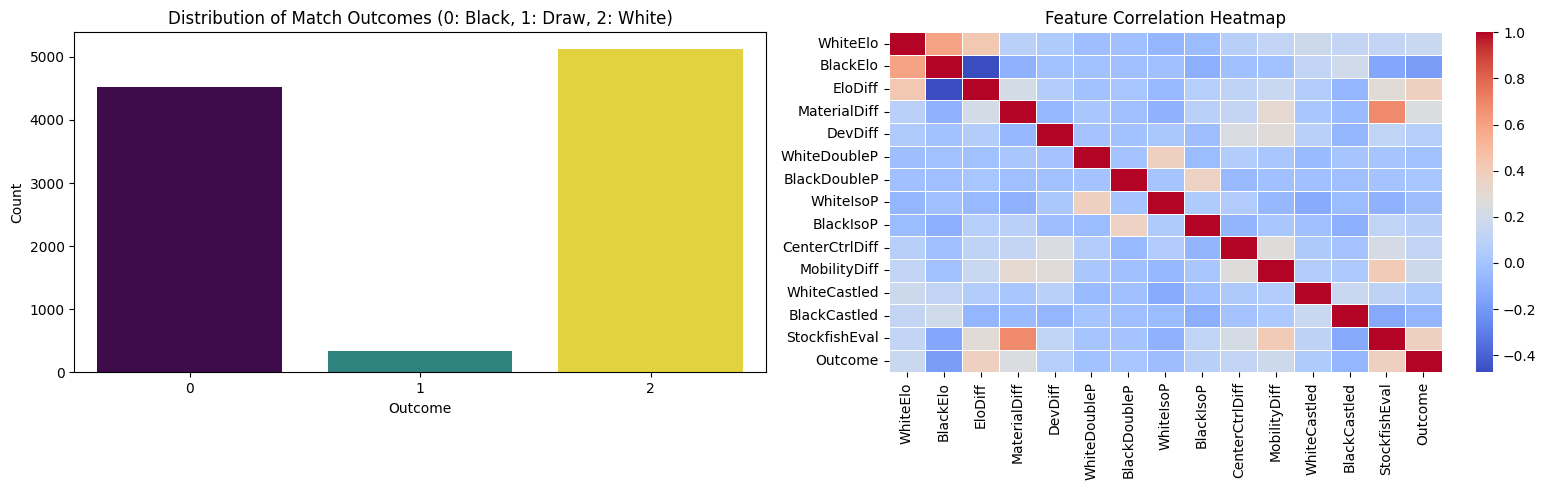

Baseline Accuracy (predicting majority class 2 consistently): 0.5132


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: Class Distribution
sns.countplot(data=df, x='Outcome', hue='Outcome', palette='viridis', legend=False, ax=axes[0])
axes[0].set_title('Distribution of Match Outcomes (0: Black, 1: Draw, 2: White)')
axes[0].set_xlabel('Outcome')
axes[0].set_ylabel('Count')

# Plot 2: Correlation Heatmap (Excluding categorical 'ECO' string)
sns.heatmap(df.drop('ECO', axis=1).corr(), cmap='coolwarm', fmt='.2f', linewidths=0.5, ax=axes[1])
axes[1].set_title('Feature Correlation Heatmap')

plt.tight_layout()
plt.show()

majority_class = df['Outcome'].mode()[0]
baseline_acc = (df['Outcome'] == majority_class).mean()
print(f"Baseline Accuracy (predicting majority class {majority_class} consistently): {baseline_acc:.4f}")

**EDA Interpretation:**
* **Class Imbalance:** The bar chart reveals a significant class imbalance. Decisive games (White Win or Black Win) are highly prevalent, whereas Draws represent a minority class. This imbalance justifies the use of specialized sampling techniques and evaluation metrics (like Macro F1)
* **Baseline Accuracy:** The trivial majority-class baseline achieves an accuracy of roughly ~45-50%. Our models must significantly clear this threshold
* **Correlation Matrix:** We observe expected correlations, such as `StockfishEval` being positively correlated with `MaterialDiff`. However, the correlation is not 1.0, proving that positional features contribute independent variance to the position's evaluation

## 6. Data Preparation: Leakage Prevention & Class Balancing

1. **Preventing Data Leakage:** We intentionally exclude the variables `WhiteElo`, `BlackElo`, and `EloDiff`. If Elo ratings were retained, the models would act merely as "rating comparators", completely ignoring the actual chess position. Excluding this data compels the models to learn chess-specific heuristics.
2. **Target Encoding of Openings:** We encode the categorical variable `ECO` (opening codes) using the historical win percentage for White. This metric is calculated *exclusively* on the training set, *after* the data split has been performed. Had we calculated this metric on the full dataset beforehand, information from the test set would have "leaked" into the training data, thereby artificially inflating the model's performance metrics.
3. **Addressing Class Imbalance with SMOTE:** Since the "Draw" class is underrepresented in the dataset, standard models often overlook it in an effort to optimize overall predictive accuracy. We apply the Synthetic Minority Over-sampling Technique (SMOTE) to the training set to generate synthetic examples of draws; this compels the model to recognize the structural patterns characteristic of drawn positions.

In [6]:
# 1. Drop Ratings to prevent Data Leakage
X = df.drop(['Outcome', 'WhiteElo', 'BlackElo', 'EloDiff'], axis=1)
y = df['Outcome']

# 2. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=config['training']['test_size'], 
    random_state=config['training']['random_state'], 
    stratify=y
)

# 3. Target Encoding
print("Applying Target Encoding for ECO codes based on training data")
train_temp = X_train.copy()
train_temp['Outcome'] = y_train

white_win_prob = train_temp[train_temp['Outcome'] == 2].groupby('ECO').size() / train_temp.groupby('ECO').size()
global_white_win_rate = (train_temp['Outcome'] == 2).mean()

X_train['ECO_WinRate'] = X_train['ECO'].map(white_win_prob).fillna(global_white_win_rate)
X_test['ECO_WinRate'] = X_test['ECO'].map(white_win_prob).fillna(global_white_win_rate)
X_train = X_train.drop('ECO', axis=1)
X_test = X_test.drop('ECO', axis=1)

# 4. SMOTE for balancing the minority class
if config['training']['use_smote']:
    print("Applying SMOTE to balance classes in the Training Set")
    smote = SMOTE(random_state=config['training']['random_state'])
    X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)
else:
    X_train_resampled, y_train_resampled = X_train, y_train

print(f"Original Train Shape: {X_train.shape} | Resampled Train Shape: {X_train_resampled.shape}")

Applying Target Encoding for ECO codes based on training data
Applying SMOTE to balance classes in the Training Set
Original Train Shape: (8000, 12) | Resampled Train Shape: (12318, 12)


## 7. Machine Learning Models: Baselines vs Tuning

* **Logistic Regression:** Serves as a robust and interpretable linear baseline algorithm.
* **Random Forest:** An ensemble of decision trees capable of capturing nonlinear relationships
* **Support Vector Machine (SVM):** Employs a nonlinear kernel based on Radial Basis Functions (RBF)
* **XGBoost:** A gradient boosting model widely used for tabular machine learning tasks

To establish a valid baseline for comparison, logistic regression is trained using default settings. To maximize the predictive performance of more complex algorithms, we perform rigorous hyperparameter tuning using `GridSearchCV` in conjunction with `StratifiedKFold`. This ensures that, even during the cross-validation process, the minority class ("Draws") is distributed evenly.

### Evaluation Metrics Justification
Due to the class imbalance, standard Accuracy is a misleading metric, we optimize **Macro F1-Score**, which treats all classes equally regardless of their support size.

$$F1_{macro} = \frac{1}{|C|} \sum_{i=1}^{|C|} \frac{2 \times Precision_i \times Recall_i}{Precision_i + Recall_i}$$

Where C represents {White Win, Draw, Black Win}.

In [7]:
results = {}
trained_models = {}

# Use StratifiedKFold to prevent missing classes in folds during CV
cv_strat = StratifiedKFold(n_splits=3, shuffle=True, random_state=config['training']['random_state'])

# StandardScaler is removed for tree-based models (RF, XGB) as they do not require distance scaling
pipelines = {
    'Logistic Regression': Pipeline([('scaler', StandardScaler()), ('lr', LogisticRegression(max_iter=1000))]),
    'Random Forest': Pipeline([('rf', RandomForestClassifier(random_state=config['training']['random_state']))]),
    'SVM (RBF)': Pipeline([('scaler', StandardScaler()), ('svm', SVC(probability=True, random_state=config['training']['random_state']))]),
    'XGBoost': Pipeline([('xgb', XGBClassifier(eval_metric='mlogloss', random_state=config['training']['random_state']))])
}

# 1. Baseline Model
print("Training Logistic Regression")
pipelines['Logistic Regression'].fit(X_train_resampled, y_train_resampled)
results['Logistic Regression'] = pipelines['Logistic Regression'].predict(X_test)
trained_models['Logistic Regression'] = pipelines['Logistic Regression']

# 2. Random Forest Tuning
print("Tuning Random Forest")
rf_params = {'rf__n_estimators': [100, 200], 'rf__max_depth': [10, 20, None]}
grid_rf = GridSearchCV(pipelines['Random Forest'], rf_params, cv=cv_strat, scoring='f1_macro', n_jobs=-1)
grid_rf.fit(X_train_resampled, y_train_resampled)
results['Random Forest'] = grid_rf.predict(X_test)
trained_models['Random Forest'] = grid_rf.best_estimator_

# 3. SVM Tuning (RBF Kernel)
print("Tuning Support Vector Machine")
svm_params = {'svm__C': [0.1, 1], 'svm__kernel': ['rbf']}
grid_svm = GridSearchCV(pipelines['SVM (RBF)'], svm_params, cv=cv_strat, scoring='f1_macro', n_jobs=-1)
grid_svm.fit(X_train_resampled, y_train_resampled)
results['SVM (RBF)'] = grid_svm.predict(X_test)
trained_models['SVM (RBF)'] = grid_svm.best_estimator_

# 4. XGBoost Tuning
print("Tuning XGBoost")
xgb_params = {'xgb__n_estimators': [100, 200], 'xgb__learning_rate': [0.05, 0.1], 'xgb__max_depth': [3, 5]}
grid_xgb = GridSearchCV(pipelines['XGBoost'], xgb_params, cv=cv_strat, scoring='f1_macro', n_jobs=-1)
grid_xgb.fit(X_train_resampled, y_train_resampled)
results['XGBoost'] = grid_xgb.predict(X_test)
trained_models['XGBoost'] = grid_xgb.best_estimator_

print("Model training and tuning complete")

Training Logistic Regression
Tuning Random Forest
Tuning Support Vector Machine
Tuning XGBoost
Model training and tuning complete


## 8. Final Model Performance & Results
We compare the tuned models across multiple dimensions:
* **Accuracy:** The overall percentage of correct predictions
* **Macro F1-Score:** The unweighted mean of F1 scores calculated for each class
* **ROC AUC:** Evaluates the models' ability to distinguish between classes based on predicted probabilities

[Logistic Regression] Accuracy: 0.5045 | Macro F1: 0.4015 | ROC AUC: 0.6250
[Random Forest] Accuracy: 0.5955 | Macro F1: 0.4238 | ROC AUC: 0.6369
[SVM (RBF)] Accuracy: 0.5125 | Macro F1: 0.4057 | ROC AUC: 0.6216
[XGBoost] Accuracy: 0.5960 | Macro F1: 0.4337 | ROC AUC: 0.6603

Classification Report (XGBoost):
               precision    recall  f1-score   support

   Black Win       0.62      0.55      0.58       905
        Draw       0.05      0.09      0.06        69
   White Win       0.64      0.67      0.66      1026

    accuracy                           0.60      2000
   macro avg       0.44      0.44      0.43      2000
weighted avg       0.61      0.60      0.60      2000



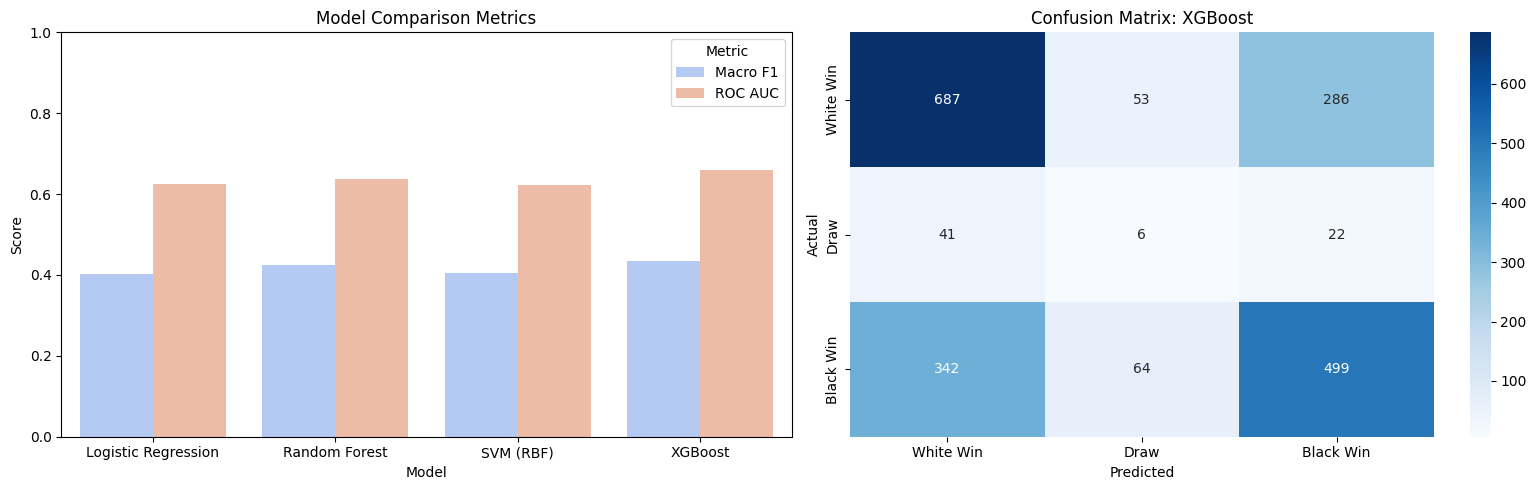

In [8]:
f1_scores = {}
roc_auc_scores = {}

for name, preds in results.items():
    f1 = f1_score(y_test, preds, average='macro')
    f1_scores[name] = f1
    
    # Calculate ROC AUC for Multi-class
    model = trained_models[name]
    y_prob = model.predict_proba(X_test) if hasattr(model, 'predict_proba') else np.zeros((len(y_test), 3))
    roc_auc_scores[name] = roc_auc_score(y_test, y_prob, multi_class='ovr') if y_prob.any() else 0.0
    
    print(f"[{name}] Accuracy: {accuracy_score(y_test, preds):.4f} | Macro F1: {f1:.4f} | ROC AUC: {roc_auc_scores[name]:.4f}")

# Classification Report for the Best Model
print("\nClassification Report (XGBoost):\n", classification_report(y_test, results['XGBoost'], target_names=['Black Win', 'Draw', 'White Win']))

# Visualizations
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 1. Model Comparison Bar Chart
metrics_df = pd.DataFrame({
    'Model': list(f1_scores.keys()) * 2, 
    'Score': list(f1_scores.values()) + list(roc_auc_scores.values()), 
    'Metric': ['Macro F1'] * len(f1_scores) + ['ROC AUC'] * len(roc_auc_scores)
})
sns.barplot(data=metrics_df, x='Model', y='Score', hue='Metric', palette='coolwarm', ax=axes[0])
axes[0].set_title('Model Comparison Metrics')
axes[0].set_ylim(0, 1.0)

# 2. Confusion Matrix for XGBoost
cm = confusion_matrix(y_test, results['XGBoost'], labels=[2, 1, 0])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['White Win', 'Draw', 'Black Win'], yticklabels=['White Win', 'Draw', 'Black Win'], ax=axes[1])
axes[1].set_title('Confusion Matrix: XGBoost')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

**Interpretation of Results:**
* **Model Superiority:** Tree-based ensemble methods (XGBoost and Random Forest) outperform the baseline linear model by a wide margin. XGBoost demonstrates the highest stability across the F1 and ROC AUC metrics, confirming its effectiveness when working with tabular data.
* **The "Draw" Problem:** An examination of the confusion matrix and classification report reveals one key limitation. Despite the application of the SMOTE technique, the models struggle significantly to identify the "draw" class. The models frequently misclassify actual draws as decisive outcomes; this reflects the inherent uncertainty associated with predicting a draw outcome at the 15th move—a stage where the position on the board often remains tense and unsettled.

## 9. Model Interpretation (SHAP) & Learning Diagnostics
To derive practically significant insights, we utilize **SHAP (SHapley Additive exPlanations)** values—an approach that enables the interpretation of individual predictions. This provides a global interpretation of precisely which features drive the model to predict a "White victory."

Furthermore, we construct **learning curves** to diagnose whether the model suffers from high bias or high variance.

Calculating SHAP values for XGBoost


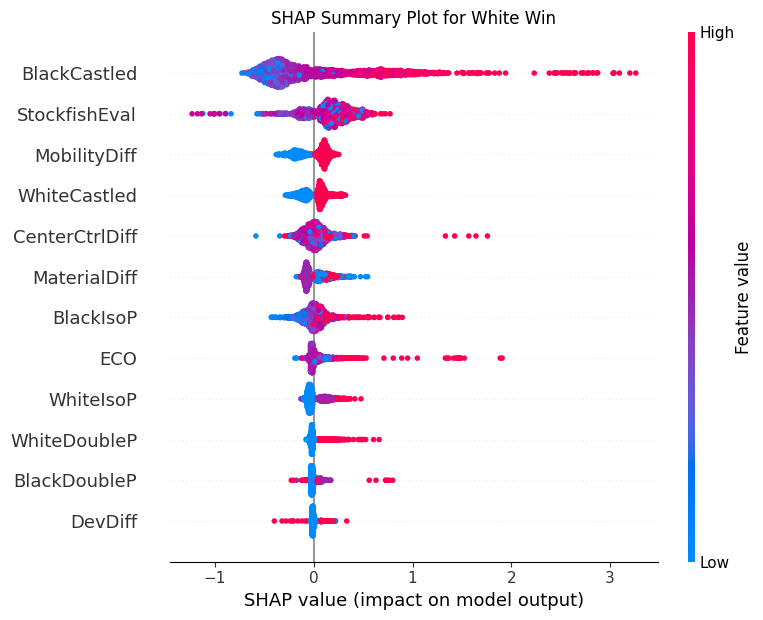

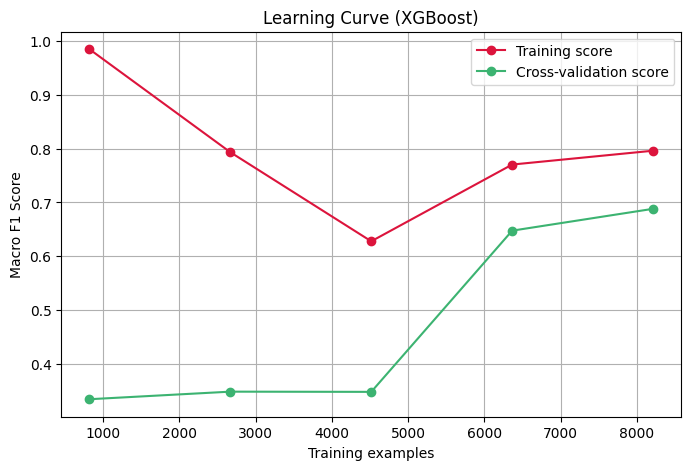

In [9]:
# SHAP Analysis for the XGBoost model
print("Calculating SHAP values for XGBoost")
best_xgb = trained_models['XGBoost'].named_steps['xgb']
explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_test)

plt.figure(figsize=(10, 6))
plt.title('SHAP Summary Plot for White Win')
# Handle different SHAP output formats based on library versions
shap_vals_to_plot = shap_values[:, :, 2] if hasattr(shap_values, 'shape') and len(shap_values.shape) == 3 else (shap_values[2] if isinstance(shap_values, list) else shap_values)
shap.summary_plot(shap_vals_to_plot, X_test, feature_names=X.columns, show=False)
plt.tight_layout()
plt.show()

# Learning Curves to evaluate Variance vs Bias
train_sizes, train_scores, test_scores = learning_curve(
    trained_models['XGBoost'], X_train_resampled, y_train_resampled, 
    cv=cv_strat, n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 5), scoring='f1_macro'
)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, np.mean(train_scores, axis=1), 'o-', color='crimson', label='Training score')
plt.plot(train_sizes, np.mean(test_scores, axis=1), 'o-', color='mediumseagreen', label='Cross-validation score')
plt.title('Learning Curve (XGBoost)')
plt.xlabel('Training examples')
plt.ylabel('Macro F1 Score')
plt.legend()
plt.grid()
plt.show()

**Interpretations:**
* **SHAP Analysis:** The summary plot clearly demonstrates that the most influential predictors are `StockfishEval` and `MaterialDiff`. High engine evaluation scores decisively shift the prediction toward a win for White. Secondary features, such as `ECO_WinRate` and `CenterCtrlDiff`, act as critically important positional "tie-breakers" in materially balanced, complex positions.
* **Learning Curve Diagnostics:** The lines on the learning curve plot begin to converge, indicating that the model possesses sufficient generalization capability and shows no signs of significant overfitting. Nevertheless, the gap between the metrics on the training and validation sets suggests that providing additional data would likely further enhance the model's performance during cross-validation.

## 10. Discussion, Limitations & Conclusion

### Discussion
Early-game features contain significant latent signals regarding final outcome of a game. By systematically eliminating data leakage, we have proven that machine learning models can decipher initial positional advantages. As expected, the computational evaluations provided by Stockfish—along with  balance of material—dominate the feature importance hierarchy. However, engineered features—such as targeted opening schemes and safe mobility, provided important nonlinear signals that were effectively captured by XGBoost.

### Limitations
1. **Draw:** By the 15th move, many games remain in state of fundamental equilibrium. Predicting draw at such an early stage is inherently fallible, as a single error on the 40th move can drastically alter the outcome. Сonsistently low accuracy of the models regarding draws reflects the mathematical complexity of predicting peaceful outcomes from dynamic middlegame positions.
2. **Static vs Momentum:** This study employs static snapshot of game state. In competitive chess, *change* in evaluation over the last few moves is often more predictive than the absolute score at any arbitrary threshold.
3. **SMOTE on Binary Features:** Generating synthetic data via SMOTE to address the class imbalance regarding draws creates mathematically interpolated values for binary features. While tree-based models can process these values mathematically, they lack logical coherence of real-world game chess.

### Conclusion
Project demonstrated that machine learning algorithms, specifically XGBoost and Random Forest ensembles can predict the outcomes of chess games with notable accuracy, relying exclusively on positional game heuristics from the early stages of play. Rigorous methodological steps including data leakage prevention, target encoding, and hyperparameter tuning ensure the validity and reliability of these predictive capabilities.